[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/Quantlets/Ch_01/SFM_ch1_seminar/SFM_ch1_seminar.ipynb)

# Statistics of Financial Markets — Seminar 1: Data, returns and indicators

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- This seminar comes before Lecture 1: the slides "What You Need for Today" give every definition used here.
- Part A: computations on paper, checked in code. Part B: real data with a measure of precision and an interpretation question. Part C: an open question and an AI answer to audit.
- **[Solved]**: complete code and output, a model to follow. **[Proposed]**: write your own code in the empty cell.

> Quantlet `SFM_ch1_seminar`: student version of the Seminar 1 notebook. Solved exercises (A1, A3, A5, A6, B1, B2, B4, B6) are shown with code and output; the proposed exercises (A2, A4, A7, B3, B5, B7, C1, C2) are not solved here (an empty code cell where they need code).

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/SFM/Chapter_1'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import sfm_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the SFM repository (read locally, or from GitHub in Colab); EUR/RON is the official BNR reference rate.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/SFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the SFM repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years

## Seminar functions

- Returns, CAGR, drawdown, Sharpe ratio with the Lo (2002) standard error, Sortino ratio, descriptive statistics.
- Helpers for Part A (short price paths) and the bootstrap of the Sharpe ratio.

In [ ]:
START = '2015-01-01'
ASSETS = ['sp500', 'dax', 'bet', 'bettr', 'btc', 'tlv', 'snp', 'brd', 'snn', 'tgn']
COLORS = {'sp500': '#1A3A6E', 'dax': '#17A2B8', 'bet': '#CD0000', 'bettr': '#E67E22', 'btc': '#B5853F', 'tlv': '#2E7D32', 'snp': '#8E44AD', 'brd': '#DC3545', 'snn': '#1A3A6E', 'tgn': '#17A2B8', 'eurron': '#2E7D32', 'eurron_eodhd': '#CD0000'}
SCATTER = {'S&P 500': ('#1A3A6E', 'o'), 'DAX': ('#17A2B8', 'o'), 'BET': ('#CD0000', 'o'), 'BET-TR': ('#E67E22', 'o'), 'Bitcoin': ('#B5853F', '*'), 'Banca Transilvania': ('#2E7D32', 's'), 'OMV Petrom': ('#8E44AD', 's'), 'BRD': ('#DC3545', 's'), 'Nuclearelectrica': ('#6D4C41', 's'), 'Transgaz': ('#C2185B', 's')}
SEM_START = '2015-01-01'


def simple_ret(p):
    """Simple (net) returns R_t = P_t / P_{t-1} - 1, as decimals."""
    return p.pct_change().dropna()


def log_ret(p):
    """Log returns r_t = ln(P_t / P_{t-1}), as decimals."""
    return np.log(p).diff().dropna()


def cagr(p):
    """Compound annual growth rate from the first and last price, over calendar years."""
    years = (p.index[-1] - p.index[0]).days / 365.25
    return (p.iloc[-1] / p.iloc[0]) ** (1 / years) - 1


def drawdown(p):
    """Drawdown DD_t = P_t / max_{s<=t} P_s - 1 (zero at a new maximum, negative below it)."""
    return p / p.cummax() - 1


def max_drawdown(p):
    """Maximum drawdown: depth, date of the previous peak, date of the trough, date of recovery (or None)."""
    dd = drawdown(p)
    trough = dd.idxmin()
    peak = p.loc[:trough].idxmax()
    after = p.loc[trough:]
    rec = after[after >= p.loc[peak]]
    return {'mdd': float(dd.min()), 'peak': peak.date().isoformat(), 'trough': trough.date().isoformat(),
            'recovery': rec.index[0].date().isoformat() if len(rec) else None}


def downside_deviation(R, target=0.0):
    """Downside deviation below a target: sqrt(mean(min(R - target, 0)^2)), over all observations."""
    return float(np.sqrt(np.mean(np.minimum(R - target, 0.0) ** 2)))


def sharpe_se(sr, n):
    """Standard error of a Sharpe ratio estimated from n i.i.d. returns (Lo, 2002): sqrt((1 + SR^2/2) / n)."""
    return float(np.sqrt((1 + 0.5 * sr ** 2) / n))


def performance(p, rf=0.0):
    """Performance indicators of one price series on its own calendar (annualised with its actual frequency)."""
    R, r = simple_ret(p), log_ret(p)
    q = periods_per_year(R)
    mu_a = R.mean() * q                                 # arithmetic annual mean of simple returns
    vol = R.std() * np.sqrt(q)                          # annualised volatility
    sr_d = (R.mean() - rf / q) / R.std()                # per-period Sharpe ratio
    sr = sr_d * np.sqrt(q)
    se = sharpe_se(sr_d, len(R)) * np.sqrt(q)
    sortino = (mu_a - rf) / (downside_deviation(R) * np.sqrt(q))
    m = max_drawdown(p)
    g = cagr(p)
    return {'n': len(R), 'obs_per_year': q, 'years': (p.index[-1] - p.index[0]).days / 365.25,
            'mean_arith': mu_a, 'mean_log': r.mean() * q, 'cagr': g, 'vol': vol,
            'drag': mu_a - r.mean() * q, 'half_var': 0.5 * vol ** 2,
            'sharpe': sr, 'sharpe_se': se, 'sharpe_lo': sr - 1.96 * se, 'sharpe_hi': sr + 1.96 * se,
            'sortino': sortino, 'mdd': m['mdd'], 'mdd_peak': m['peak'], 'mdd_trough': m['trough'],
            'mdd_recovery': m['recovery'], 'calmar': g / abs(m['mdd'])}


def describe(r):
    """Descriptive statistics of daily log returns (in %): moments, extremes and the precision of the mean."""
    q = periods_per_year(r)
    return {'n': len(r), 'obs_per_year': q, 'mean': r.mean(), 'sd': r.std(), 'skew': stats.skew(r),
            'exkurt': stats.kurtosis(r), 'min': r.min(), 'min_date': r.idxmin().date().isoformat(),
            'max': r.max(), 'max_date': r.idxmax().date().isoformat(), 'q01': r.quantile(0.01),
            'q99': r.quantile(0.99), 'ann_mean': r.mean() * q, 'ann_vol': r.std() * np.sqrt(q),
            'se_ann_mean': r.std() * np.sqrt(q) / np.sqrt(len(r) / q)}


def returns_table(prices):
    """Simple and log returns (in %) of a short price path, and their two-period totals."""
    p = np.asarray(prices, dtype=float)
    R = p[1:] / p[:-1] - 1
    r = np.log(p[1:] / p[:-1])
    return {'R': list(100 * R), 'r': list(100 * r), 'R_total': 100 * (p[-1] / p[0] - 1),
            'R_compound': 100 * (np.prod(1 + R) - 1), 'R_sum': 100 * R.sum(),
            'r_sum': 100 * r.sum(), 'r_total': 100 * np.log(p[-1] / p[0])}


def adjusted_prices(prices, events):
    """Adjusted prices: events = {day index: factor}; every earlier price is multiplied by the later factors."""
    p = np.asarray(prices, dtype=float)
    adj = p.copy()
    for day, f in events.items():
        adj[:day] *= f
    return adj


def path_indicators(prices, q):
    """Indicators of a short price path with q observations per year (risk-free rate 0)."""
    p = pd.Series(np.asarray(prices, dtype=float))
    R = p.pct_change().dropna()
    mu, sd = R.mean(), R.std()
    dd = p / p.cummax() - 1
    years = (len(p) - 1) / q
    g = (p.iloc[-1] / p.iloc[0]) ** (1 / years) - 1
    dsd = float(np.sqrt(np.mean(np.minimum(R, 0) ** 2)))
    return {'R': list(100 * R), 'mean': 100 * mu, 'sd': 100 * sd, 'mean_ann': 100 * mu * q, 'vol_ann': 100 * sd * np.sqrt(q),
            'sharpe': mu / sd * np.sqrt(q), 'dsd': 100 * dsd, 'sortino': mu / dsd * np.sqrt(q), 'mdd': 100 * dd.min(),
            'peak': int(p.loc[:dd.idxmin()].idxmax()), 'trough': int(dd.idxmin()), 'cagr': 100 * g,
            'calmar': g / abs(dd.min()), 'years': years}


def bootstrap_sharpe(R, q, B=2000, seed=1):
    """i.i.d. bootstrap of the annualised Sharpe ratio (risk-free rate 0): resample days with replacement."""
    rng = np.random.default_rng(seed)
    x = np.asarray(R)
    idx = rng.integers(0, len(x), size=(B, len(x)))
    s = x[idx]
    return s.mean(axis=1) / s.std(axis=1, ddof=1) * np.sqrt(q)

# Part A: computations on paper

- Do each computation on paper first; then check it with the code.

## A1 [Solved]: simple and log returns over two days

**Context.** A share closes at 50, 55 and 48 lei on three consecutive days.

1. Compute the two daily simple returns and the two daily log returns.
2. Compute the two-day simple return from the prices and by compounding.
3. Check whether the sum of the simple returns and the sum of the log returns equal the two-day returns.

**Report:** four daily returns, two two-day returns, one sentence on which returns add up.

In [6]:
# Solution
returns_table([50, 55, 48])

{'R': [np.float64(10.000000000000009), np.float64(-12.727272727272732)],
 'r': [np.float64(9.531017980432493), np.float64(-13.613217432458006)],
 'R_total': np.float64(-4.0000000000000036),
 'R_compound': np.float64(-3.9999999999999925),
 'R_sum': np.float64(-2.7272727272727226),
 'r_sum': np.float64(-4.082199452025511),
 'r_total': np.float64(-4.082199452025517)}

**Interpretation of the result.** The log returns add up to $\ln(48/50)$; the simple returns must be compounded.

## A2 [Proposed]: a three-day path

**Context.** A share closes at 80, 100, 75 and 90 lei. Model: A1.

1. Compute the three daily simple returns and the three daily log returns.
2. Compute the three-day simple return from the first and last price and by compounding.
3. Explain why the sum of the simple returns overstates the three-day return.

**Report:** six daily returns, the three-day simple and log returns, one sentence.

In [ ]:
# Your code here


## A3 [Solved]: a dividend and a split

**Context.** Closes on days 0-6: 30, 31, 30.5, 29.2, 29.8, 10.1, 10.3. Dividend of 1.5 on day 3; 3-for-1 split on day 5.

1. Compute the adjustment factor of each event.
2. Compute the adjusted prices of days 0-6.
3. Compare the raw and the adjusted return of day 5.

**Report:** two factors, seven adjusted prices, two returns.

In [8]:
# Solution
prices = [30, 31, 30.5, 29.2, 29.8, 10.1, 10.3]
factors = {3: 1 - 1.5 / 30.5, 5: 1 / 3}
adj = adjusted_prices(prices, factors)
print('factors:', {k: round(v, 4) for k, v in factors.items()})
print('adjusted:', np.round(adj, 2))
print('day 5, raw: %.1f%%, adjusted: %.1f%%' % (100 * (prices[5] / prices[4] - 1), 100 * (adj[5] / adj[4] - 1)))

factors: {3: 0.9508, 5: 0.3333}
adjusted: [ 9.51  9.83  9.67  9.73  9.93 10.1  10.3 ]
day 5, raw: -66.1%, adjusted: 1.7%


## A4 [Proposed]: a dividend and a consolidation

**Context.** Closes on days 0-5: 2.05, 2.10, 1.95, 1.98, 19.90, 20.40. Dividend of 0.18 on day 2; ten old shares consolidated into one on day 4. Model: A3.

1. Compute the adjustment factor of each event.
2. Compute the adjusted prices of days 0-5.
3. Compute the raw log return of day 4 and say what it would do to a volatility estimate.

**Report:** two factors, six adjusted prices, one return and one sentence.

In [ ]:
# Your code here


## A5 [Solved]: from daily moments to annual indicators

**Context.** Daily log returns with mean 0.06% and standard deviation 1.5%; 250 trading days a year; 10 years of data.

1. Compute the annual mean log return and the annual volatility.
2. Compute the CAGR and the annual mean of simple returns implied by the volatility drag.
3. Compute the standard error and the 95% CI of the annual mean log return.

**Report:** five numbers and one sentence.

In [10]:
# Solution
m, s, A, Y = 0.0006, 0.015, 250, 10
mu, vol = m * A, s * np.sqrt(A)
se = vol / np.sqrt(Y)
print('annual mean log return %.1f%%, volatility %.1f%%' % (100 * mu, 100 * vol))
print('CAGR %.1f%%, arithmetic mean %.1f%% (drag %.2f%%)' % (100 * (np.exp(mu) - 1), 100 * (mu + vol**2 / 2), 100 * vol**2 / 2))
print('SE %.1f%%, 95%% CI [%.1f%%, %.1f%%]' % (100 * se, 100 * (mu - 1.96 * se), 100 * (mu + 1.96 * se)))

annual mean log return 15.0%, volatility 23.7%
CAGR 16.2%, arithmetic mean 17.8% (drag 2.81%)
SE 7.5%, 95% CI [0.3%, 29.7%]


## A6 [Solved]: indicators of a short price path

**Context.** Month-end values of a fund: 100, 104, 101, 107, 99, 103, 110 ($A = 12$, $r_f = 0$).

1. Compute the monthly simple returns, their mean and standard deviation.
2. Compute the annualised Sharpe and Sortino ratios.
3. Compute the MDD, the CAGR and the Calmar ratio.

**Report:** a table of returns, five indicators, one sentence on why Sortino exceeds Sharpe.

In [11]:
# Solution
pd.Series(path_indicators([100, 104, 101, 107, 99, 103, 110], q=12))

R           [4.0000000000000036, -2.8846153846153855, 5.94...
mean                                                 1.735977
sd                                                   5.655831
mean_ann                                            20.831727
vol_ann                                             19.592372
sharpe                                               1.063257
dsd                                                  3.271623
sortino                                               1.83811
mdd                                                 -7.476636
peak                                                        3
trough                                                      4
cagr                                                     21.0
calmar                                                2.80875
years                                                     0.5
dtype: object

## A7 [Proposed]: indicators of another fund

**Context.** Month-end values: 200, 190, 205, 215, 180, 196, 210, 222 ($A = 12$, $r_f = 0$). Model: A6.

1. Compute the monthly simple returns, their mean and standard deviation.
2. Compute the annualised Sharpe and Sortino ratios.
3. Compute the MDD, the CAGR and the Calmar ratio.
4. Compare with A6: which indicators rank the two funds differently?

**Report:** five indicators and one sentence.

In [ ]:
# Your code here


# Part B: real data, precision and interpretation

## B1 [Solved]: can we trust a EUR/RON series?

**Question.** Do the EUR/RON series from EODHD and the BNR reference rate describe the same exchange rate?

1. Compute the daily log returns of both series on the common days.
2. Count the days on which the two returns differ by more than one percentage point.
3. Compute the annualised volatility of each series, and of the EODHD series without those days.
4. Interpretation: which series would you use to measure the currency risk of a EUR loan, and why?

**Report:** the number of days, three volatilities, one sentence.

{'n': 5154,
 'n_big': 412,
 'share_big': 0.07993791230112533,
 'vol_bnr': np.float64(4.50020252010574),
 'vol_eodhd': np.float64(13.418027157591853),
 'worst_year': 2011,
 'worst_year_n': 107,
 'vol_eodhd_clean': 4.655525020513549}

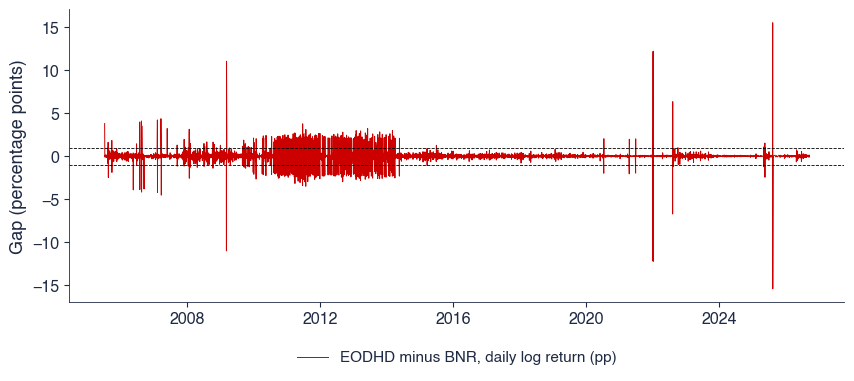

In [13]:
# Solution
def b1_eurron(save=True):
    """EUR/RON from EODHD vs the BNR reference rate: the gap between the daily log returns."""
    x = pd.concat([load_close('eurron'), load_close('eurron_eodhd')], axis=1).dropna()
    r = 100 * np.log(x).diff().dropna()
    gap = r['eurron_eodhd'] - r['eurron']
    fig, ax = plt.subplots(figsize=(10, 3.8))
    ax.plot(gap.index, gap, color=st.COL['bet'], lw=0.7, label='EODHD minus BNR, daily log return (pp)')
    ax.axhline(1, color='black', lw=0.6, ls='--')
    ax.axhline(-1, color='black', lw=0.6, ls='--')
    ax.set_ylabel('Gap (percentage points)')
    st.legend_outside_bottom(ax, ncol=1, y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig('ch1_sem_b1')
    q = periods_per_year(r)
    big = gap.abs().sort_values(ascending=False)
    yrs = gap[gap.abs() > 1].groupby(gap[gap.abs() > 1].index.year).size()
    return {'n': len(r), 'n_big': int((gap.abs() > 1).sum()), 'share_big': float((gap.abs() > 1).mean()),
            'vol_bnr': r['eurron'].std() * np.sqrt(q), 'vol_eodhd': r['eurron_eodhd'].std() * np.sqrt(q),
            'top': [{'date': d.date().isoformat(), 'gap': float(gap.loc[d]), 'eodhd': float(r.loc[d, 'eurron_eodhd']),
                     'bnr': float(r.loc[d, 'eurron'])} for d in big.index[:3]],
            'worst_year': int(yrs.idxmax()), 'worst_year_n': int(yrs.max()),
            'vol_eodhd_clean': float(r['eurron_eodhd'][gap.abs() <= 1].std() * np.sqrt(q))}


res = b1_eurron(save=False)
{k: v for k, v in res.items() if k != 'top'}

**Interpretation of the result.** Use the BNR reference rate, the official owner of the number: the EODHD series has erroneous quotes that inflate the volatility.

## B2 [Solved]: is the mean return of the BET positive?

**Question.** Is the mean daily return of the BET significantly different from zero over 2015-2026?

1. Compute the mean, standard deviation, skewness, excess kurtosis, minimum (with its date) and maximum of the daily log returns.
2. Annualise the mean and the standard deviation with the actual number of observations per year.
3. Compute the standard error of the annual mean, its 95% CI and the $z$ statistic of $H_0$: mean $= 0$.
4. Interpretation: does the histogram look like the Normal distribution, and what does the CI tell an investor?

**Report:** a table of statistics, the CI, $z$ and $p$, two sentences.

n                     2925
obs_per_year    250.024865
mean              0.052903
sd                0.982848
skew             -1.414259
exkurt           17.846978
min             -11.892007
min_date        2018-12-19
max               6.816861
max_date        2018-12-24
q01              -2.719548
q99               2.366921
ann_mean         13.226993
ann_vol          15.540961
se_ann_mean       4.543668
ci_lo             4.321404
ci_hi            22.132581
t                 2.911083
p                 0.003602
years            11.698836
dtype: object

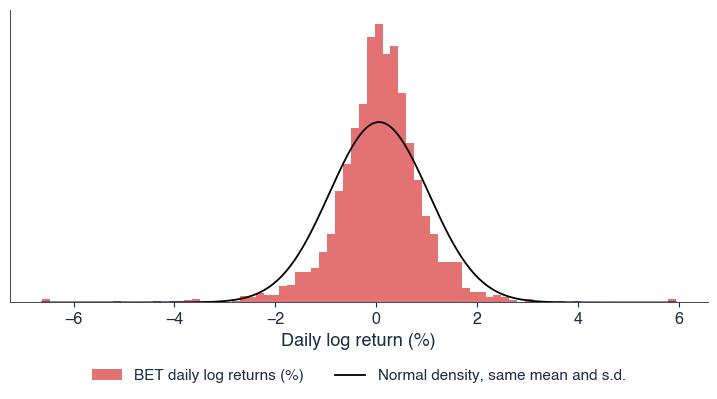

In [14]:
# Solution
def b2_mean_ci(name, start=SEM_START):
    """Descriptive statistics of daily log returns (%) and a 95% interval for the annual mean."""
    d = describe(log_returns(name, start))
    d['ci_lo'] = d['ann_mean'] - 1.96 * d['se_ann_mean']
    d['ci_hi'] = d['ann_mean'] + 1.96 * d['se_ann_mean']
    d['t'] = d['ann_mean'] / d['se_ann_mean']
    d['p'] = float(2 * stats.norm.sf(abs(d['t'])))
    d['years'] = d['n'] / d['obs_per_year']
    return d


def b2_chart(name='bet', start=SEM_START, save=True):
    """Histogram of daily BET log returns with the Normal density of the same mean and s.d."""
    r = log_returns(name, start)
    fig, ax = plt.subplots(figsize=(9, 3.8))
    lo, hi = r.quantile(0.001), r.quantile(0.999)
    ax.hist(r.clip(lo, hi), bins=80, density=True, color=st.COL[name], alpha=0.55, label=f'{LABELS[name]} daily log returns (%)')
    x = np.linspace(lo, hi, 300)
    ax.plot(x, stats.norm.pdf(x, r.mean(), r.std()), color='black', lw=1.3, label='Normal density, same mean and s.d.')
    ax.set_xlabel('Daily log return (%)')
    ax.set_yticks([])
    st.legend_outside_bottom(ax, ncol=2, y=-0.18)
    st.check_no_grey(fig)
    if save:
        st.save_fig('ch1_sem_b2')


b2_chart(save=False)
pd.Series(b2_mean_ci('bet'))

**Interpretation of the result.** A taller centre and heavier tails than the Normal distribution; the mean is positive, but the interval is wide.

## B3 [Proposed]: four more markets

**Question.** Which of the S&P 500, DAX, Bitcoin and Banca Transilvania have a mean return significantly above zero? Model: B2.

1. Repeat steps 1-3 of B2 for each of the four series.
2. Put the annual mean, the volatility, the CI and $p$ of all five series (with the BET) in one table.
3. Interpretation: why is the interval of Bitcoin so much wider than that of the S&P 500?

**Report:** one table and two sentences.

In [ ]:
# Your code here


## B4 [Solved]: how precise is a Sharpe ratio?

**Question.** How precisely is the Sharpe ratio of the S&P 500 estimated from 2015-2026 data?

1. Compute the daily mean, standard deviation and Sharpe ratio, and annualise the Sharpe ratio.
2. Compute the standard error of Lo (2002) and the 95% CI.
3. Bootstrap the Sharpe ratio with 2000 resamples of the days and take the 2.5% and 97.5% percentiles.
4. Interpretation: could the true Sharpe ratio of the S&P 500 be below 0.25?

**Report:** the Sharpe ratio, two intervals and one sentence.

In [16]:
# Solution
def b4_sharpe(name='sp500', start=SEM_START, B=2000, save=True):
    """Sharpe ratio of daily simple returns: Lo (2002) interval and bootstrap percentile interval."""
    R = simple_ret(load_close(name, start))
    q = periods_per_year(R)
    sr_d = R.mean() / R.std()
    sr = sr_d * np.sqrt(q)
    se = sharpe_se(sr_d, len(R)) * np.sqrt(q)
    bs = bootstrap_sharpe(R, q, B)
    if save:
        fig, ax = plt.subplots(figsize=(9, 3.8))
        ax.hist(bs, bins=60, density=True, color=st.COL['sp500'], alpha=0.6, label='Bootstrap Sharpe ratios (2000 resamples)')
        ax.axvline(sr, color=st.COL['bet'], lw=1.5, label='Estimate')
        ax.axvline(np.percentile(bs, 2.5), color='black', lw=1, ls='--', label='2.5% and 97.5% percentiles')
        ax.axvline(np.percentile(bs, 97.5), color='black', lw=1, ls='--')
        ax.set_xlabel('Annualised Sharpe ratio')
        ax.set_yticks([])
        st.legend_outside_bottom(ax, ncol=3, y=-0.18)
        st.check_no_grey(fig)
        st.save_fig('ch1_sem_b4')
    return {'n': len(R), 'q': q, 'mean_d': 100 * R.mean(), 'sd_d': 100 * R.std(), 'sr_d': sr_d, 'sr': sr, 'se': se,
            'lo': sr - 1.96 * se, 'hi': sr + 1.96 * se, 'bs_lo': float(np.percentile(bs, 2.5)),
            'bs_hi': float(np.percentile(bs, 97.5)), 'bs_sd': float(bs.std())}


pd.Series(b4_sharpe(save=False))

n         2943.000000
q          251.504621
mean_d       0.050830
sd_d         1.112672
sr_d         0.045683
sr           0.724484
se           0.292485
lo           0.151213
hi           1.297756
bs_lo        0.172712
bs_hi        1.262418
bs_sd        0.289878
dtype: float64

**Interpretation of the result.** Yes: both intervals are wide; a decade of daily data does not pin down a Sharpe ratio.

## B5 [Proposed]: is Banca Transilvania better than the BET?

**Question.** Is the Sharpe ratio of TLV significantly higher than that of the BET? Model: B4.

1. Join the two price series on their common days, then compute daily simple returns.
2. Compute both annualised Sharpe ratios with their Lo standard errors.
3. Bootstrap the difference of the two Sharpe ratios, resampling the same days for both series.
4. Interpretation: why must the days be resampled in pairs?

**Report:** two Sharpe ratios, the difference with its interval, one sentence.

In [ ]:
# Your code here


## B6 [Solved]: the deepest fall of the BET

**Question.** How deep was the worst fall of the BET since its launch, and how long did the recovery take?

1. Compute the drawdown series and the maximum drawdown with the dates of the peak, the trough and the recovery.
2. Compute the gain needed to recover and the share of days spent more than 20% below the peak.
3. Compute the CAGR, the MDD and the Calmar ratio over 2015-2026.
4. Interpretation: what does the drawdown add to what the volatility already tells us?

**Report:** the MDD with three dates, two percentages, three indicators, one sentence.

In [18]:
# Solution
def b6_drawdown(name='bet', start='1997-09-19', save=True):
    """Underwater curve of the BET since launch; the maximum drawdown with its dates; Calmar 2015-2026."""
    p = load_close(name, start)
    dd = 100 * drawdown(p)
    if save:
        fig, ax = plt.subplots(figsize=(10, 3.8))
        ax.fill_between(dd.index, dd, 0, color=st.COL[name], alpha=0.35, label=f'{LABELS[name]} drawdown (%)')
        ax.plot(dd.index, dd, color=st.COL[name], lw=0.8, label='_')
        ax.set_ylabel('Drawdown (%)')
        st.legend_outside_bottom(ax, ncol=1, y=-0.12)
        st.check_no_grey(fig)
        st.save_fig('ch1_sem_b6')
    m = max_drawdown(p)
    perf = performance(load_close(name, SEM_START))
    days = (pd.Timestamp(m['recovery']) - pd.Timestamp(m['peak'])).days if m['recovery'] else None
    return {'mdd': 100 * m['mdd'], 'peak': m['peak'], 'trough': m['trough'], 'recovery': m['recovery'],
            'peak_level': float(p.loc[m['peak']]), 'trough_level': float(p.loc[m['trough']]),
            'years_to_recover': days / 365.25 if days else None, 'need': 100 * (1 / (1 + m['mdd']) - 1),
            'share_below20': float((dd < -20).mean()), 'cagr': 100 * perf['cagr'], 'mdd_period': 100 * perf['mdd'],
            'calmar': perf['calmar'], 'period_peak': perf['mdd_peak'], 'period_trough': perf['mdd_trough']}


pd.Series(b6_drawdown(save=False))

mdd                 -82.548441
peak                2007-07-24
trough              2009-02-25
recovery            2021-03-16
peak_level            10813.59
trough_level           1887.14
years_to_recover     13.645448
need                473.014721
share_below20         0.564743
cagr                 14.138105
mdd_period          -31.124049
calmar                 0.45425
period_peak         2020-01-23
period_trough       2020-03-23
dtype: object

**Interpretation of the result.** Volatility ignores the order of returns; the drawdown shows how long an investor stays below the starting level.

## B7 [Proposed]: Bitcoin, OMV Petrom and the volatility drag

**Question.** How deep are the drawdowns of Bitcoin and SNP, and does the volatility-drag formula hold? Model: B6.

1. Compute the MDD of each series with the dates of the peak, the trough and the recovery.
2. Compute the CAGR and the Calmar ratio of each series.
3. Compute the arithmetic annual mean of simple returns, the annual mean of log returns and their difference.
4. Compare the difference with $\sigma^2/2$.
5. Interpretation: for which asset does the drag matter for a long-term investor?

**Report:** one table and one sentence.

In [ ]:
# Your code here


# Part C: open questions and AI critique

## C1 [Proposed]: do Sharpe ratios persist?

**Question.** Does a BVB stock with a high Sharpe ratio in 2015-2020 also have a high one in 2021-2026? Models: B4, B6.

1. Compute the annualised Sharpe ratio and its standard error for each stock in each half.
2. Compute the Spearman rank correlation between the two halves.
3. Propose one way to make the answer more reliable.
4. Interpretation: what can six stocks tell us about persistence?

**Report:** a table, the rank correlation with its $p$-value, a short project plan.

In [ ]:
# Your code here


## C2 [Proposed]: audit an AI answer

**Context.** An AI assistant compared Bitcoin and the BET over 2015-2026 and claimed:

- (a) the annual volatility of Bitcoin is its daily volatility times $\sqrt{252}$;
- (b) Bitcoin's higher Sharpe ratio proves that it is the better investment;
- (c) Bitcoin's maximum drawdown is its worst daily return;
- (d) the log return of a 50/50 portfolio is exactly the average of the two log returns;
- (e) for TLV the close column is the right price.

1. For each statement, say whether it is correct; if not, give the correct statement and the correct number.

**Report:** five verdicts with one line of justification each.

In [ ]:
# Your code here
